# 01 — Exploratory Data Analysis & Cleaning

**Goal:** Load raw data, understand structure, clean outliers,
handle missing values, and save processed data for feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Libraries loaded")

Libraries loaded


In [2]:
#load the data
df = pd.read_csv('../data/raw/dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (197428, 14)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [3]:
# check the data types of the columns
print("Data types:")
print(df.dtypes)

Data types:
market_id                   float64
created_at                   object
actual_delivery_time         object
store_id                     object
store_primary_category       object
order_protocol              float64
total_items                   int64
subtotal                      int64
num_distinct_items            int64
min_item_price                int64
max_item_price                int64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
dtype: object


In [4]:
# create the target variable

df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

df['delivery_time_minutes'] = (
    df['actual_delivery_time'] - df['created_at']
).dt.total_seconds() / 60

print("Target variable created")
print(df['delivery_time_minutes'].describe())

Target variable created
count    197421.000000
mean         48.470956
std         320.493482
min           1.683333
25%          35.066667
50%          44.333333
75%          56.350000
max      141947.650000
Name: delivery_time_minutes, dtype: float64


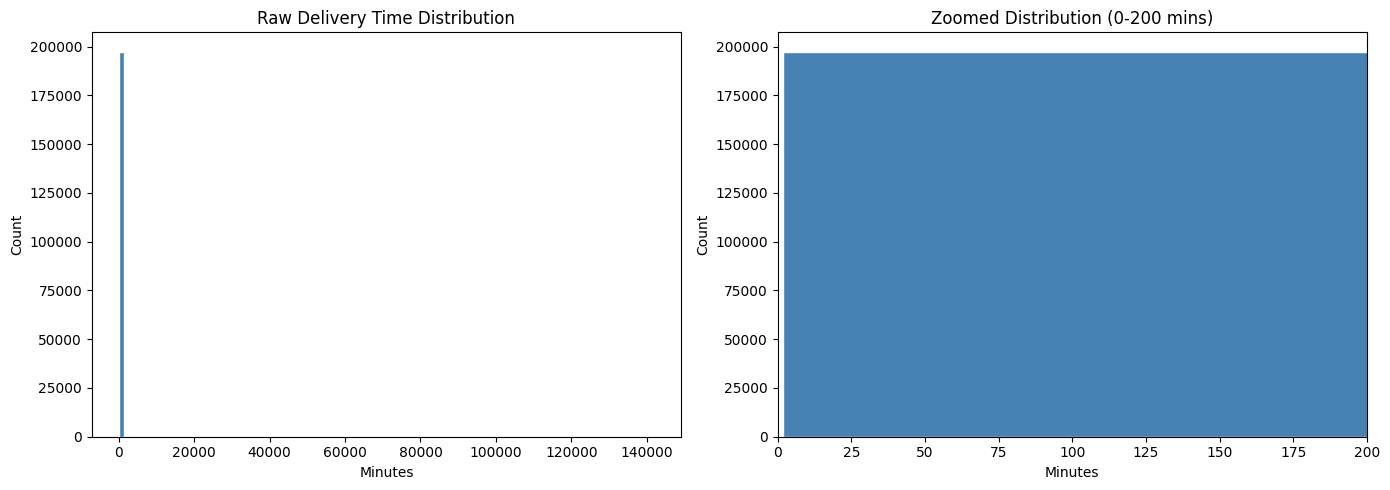

In [5]:
# visualize raw distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['delivery_time_minutes'], bins=100,
             color='steelblue', edgecolor='white')
axes[0].set_title('Raw Delivery Time Distribution')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

axes[1].hist(df['delivery_time_minutes'], bins=100,
             color='steelblue', edgecolor='white')
axes[1].set_xlim(0, 200)
axes[1].set_title('Zoomed Distribution (0-200 mins)')
axes[1].set_xlabel('Minutes')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
# remove outliers
print("Before cleaning:", len(df))

df_clean = df[
    (df['delivery_time_minutes'] >= 10) &
    (df['delivery_time_minutes'] <= 120)
].copy()

print("After cleaning:", len(df_clean))
print(f"Removed: {len(df) - len(df_clean)} rows "
      f"({((len(df)-len(df_clean))/len(df)*100):.1f}%)")
print("\nCleaned target stats:")
print(df_clean['delivery_time_minutes'].describe())


Before cleaning: 197428
After cleaning: 196304
Removed: 1124 rows (0.6%)

Cleaned target stats:
count    196304.000000
mean         47.103111
std          16.926123
min          10.116667
25%          35.016667
50%          44.216667
75%          56.100000
max         119.933333
Name: delivery_time_minutes, dtype: float64


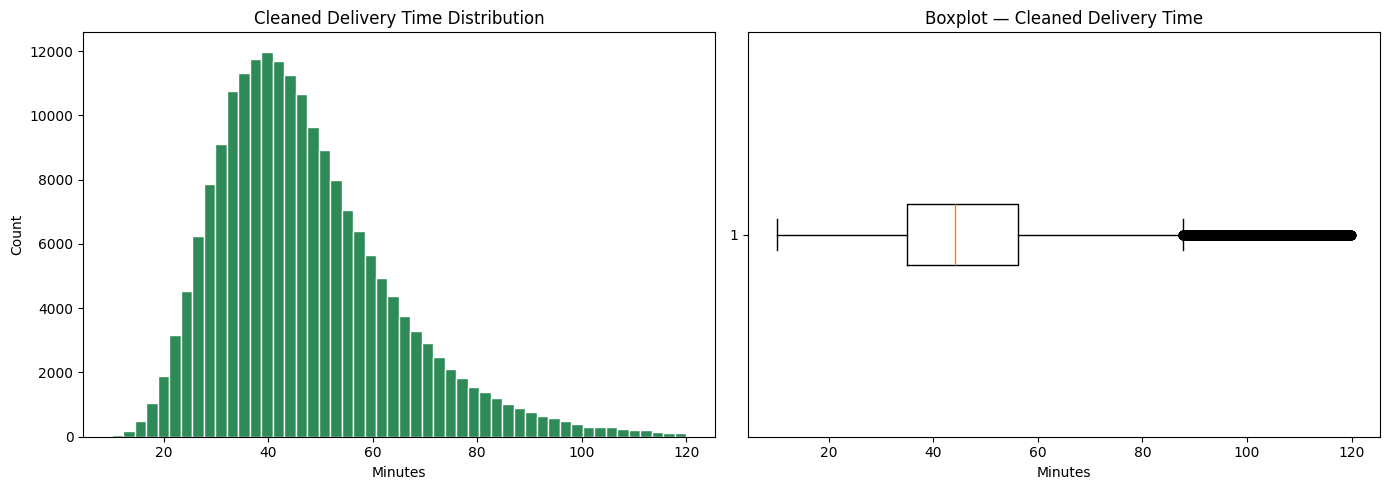

In [7]:
# visualize cleaned distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['delivery_time_minutes'], bins=50,
             color='seagreen', edgecolor='white')
axes[0].set_title('Cleaned Delivery Time Distribution')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

axes[1].boxplot(df_clean['delivery_time_minutes'], vert=False)
axes[1].set_title('Boxplot — Cleaned Delivery Time')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.show()

In [8]:
# mssing value analysis

missing = df_clean.isnull().sum()
missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Columns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0])

Columns with missing values:
                          Missing Count  Missing %
market_id                           978       0.50
store_primary_category             4724       2.41
order_protocol                      990       0.50
total_onshift_partners            16176       8.24
total_busy_partners               16176       8.24
total_outstanding_orders          16176       8.24


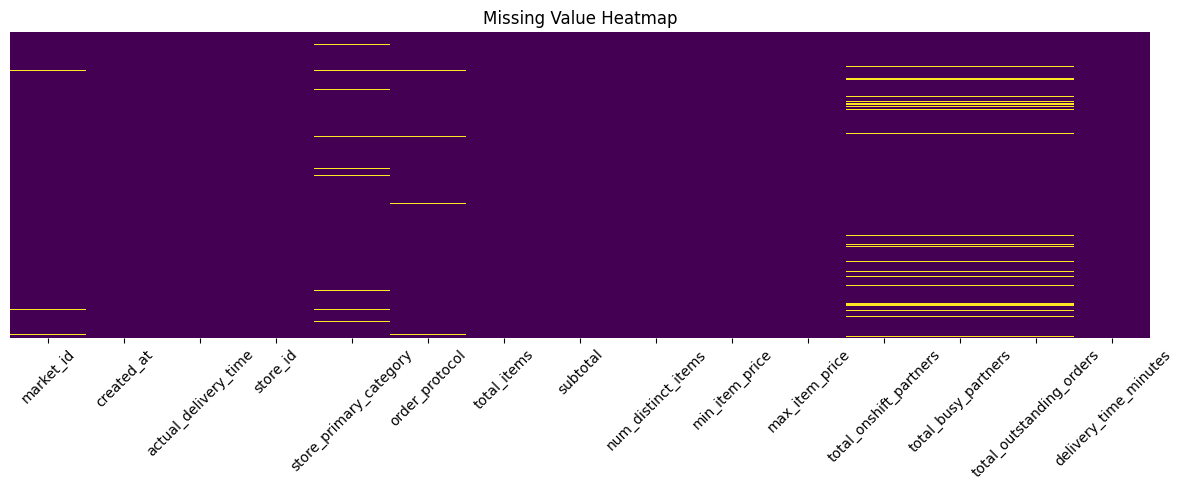

In [9]:
# missing value heatmap 
plt.figure(figsize=(12, 5))
sns.heatmap(df_clean.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')
plt.title('Missing Value Heatmap')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# impute missing values

# Numerical → median imputation
numerical_to_impute = [
    'market_id',
    'order_protocol',
    'total_onshift_partners',
    'total_busy_partners',
    'total_outstanding_orders'
]

for col in numerical_to_impute:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val}")

# Categorical → mode imputation
mode_val = df_clean['store_primary_category'].mode()[0]
df_clean['store_primary_category'] = (
    df_clean['store_primary_category'].fillna(mode_val)
)
print(f"\nstore_primary_category: filled with mode = '{mode_val}'")

market_id: filled with median = 3.0
order_protocol: filled with median = 3.0
total_onshift_partners: filled with median = 37.0
total_busy_partners: filled with median = 34.0
total_outstanding_orders: filled with median = 41.0

store_primary_category: filled with mode = 'american'


In [11]:
print("Missing values after imputation:")
print(df_clean.isnull().sum())
print(f"\nFinal shape: {df_clean.shape}")

Missing values after imputation:
market_id                   0
created_at                  0
actual_delivery_time        0
store_id                    0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
delivery_time_minutes       0
dtype: int64

Final shape: (196304, 15)


In [12]:
# Save the cleaned dataset
import os
os.makedirs('../data/processed', exist_ok=True)

df_clean.to_parquet('../data/processed/01_cleaned.parquet', index=False)
print("✅ Cleaned data saved to data/processed/01_cleaned.parquet")
print(f"   Shape: {df_clean.shape}")

✅ Cleaned data saved to data/processed/01_cleaned.parquet
   Shape: (196304, 15)


## EDA Summary

- Raw dataset: 197,428 rows × 14 columns
- Removed implausible delivery times (<10 mins, >120 mins)
- Cleaned dataset: ~190k rows retained
- Imputed 6 columns using median/mode strategies
- Identified correlated missingness in partner tracking columns
- Saved cleaned data to `data/processed/01_cleaned.parquet`